# Phase 2 — Baseline: Cosine KNN + Connected Components

**Pipeline:**
1. Load precomputed CLIP image (768d) + text (512d) embeddings
2. Concat → 1280d joint embedding, L2-normalise
3. Batched cosine KNN on MPS (block matmul, top-K=20)
4. Optional mutual KNN filter (keeps only bidirectional edges)
5. `scipy.sparse.csgraph.connected_components` → cluster IDs
6. Validate on `items_train` subsample with pairwise F1
7. Sanity-check: print random clusters with titles
8. Apply to `items_phase_2.csv` → submission CSV

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) != 'notebooks' else os.getcwd())

import torch
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from collections import defaultdict
import random

NOTEBOOK_DIR = '/Users/matouskovar/FIT/adm-sp/notebooks'
DATA_DIR     = '/Users/matouskovar/FIT/adm-sp/data'

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


## 1. Load embeddings

In [2]:
print('Loading CLIP image embeddings...')
clip_emb_dict = torch.load(f'{NOTEBOOK_DIR}/clip_embeddings.pt', map_location='cpu', weights_only=False)
print(f'  Image embeddings: {len(clip_emb_dict):,} items, dim={next(iter(clip_emb_dict.values())).shape[0]}')

print('Loading text embeddings...')
text_emb_dict = torch.load(f'{NOTEBOOK_DIR}/text_embeddings.pt', map_location='cpu', weights_only=False)
print(f'  Text embeddings:  {len(text_emb_dict):,} items, dim={next(iter(text_emb_dict.values())).shape[0]}')

Loading CLIP image embeddings...
  Image embeddings: 1,128,069 items, dim=768
Loading text embeddings...
  Image embeddings: 1,128,069 items, dim=768
Loading text embeddings...
  Text embeddings:  1,128,069 items, dim=512
  Text embeddings:  1,128,069 items, dim=512


## 2. Build embedding matrix for a given set of item IDs

In [3]:
def build_embedding_matrix(item_ids, clip_dict, text_dict, img_dim=768, txt_dim=512):
    """
    Concat image + text embeddings into (N, 1280) matrix.
    Items missing from either dict get zero vectors.
    Returns: L2-normalised float32 tensor (N, 1280), list of kept item_ids (str).
    """
    img_zero = torch.zeros(img_dim)
    txt_zero = torch.zeros(txt_dim)

    rows = []
    for iid in item_ids:
        iid_s = str(iid)
        img = clip_dict.get(iid_s, img_zero)
        txt = text_dict.get(iid_s, txt_zero)
        rows.append(torch.cat([img, txt]))

    mat = torch.stack(rows)          # (N, 1280)
    norms = mat.norm(dim=1, keepdim=True).clamp(min=1e-8)
    mat = mat / norms                # L2-normalise
    return mat

print('build_embedding_matrix() defined.')

build_embedding_matrix() defined.


## 3. Batched cosine KNN (MPS-friendly)

In [4]:
def batched_cosine_knn(mat, top_k=20, block_size=512, sim_threshold=0.85,
                        mutual=True, device=device):
    """
    For each row i, find top_k most similar rows j (j != i) using block matmul.
    Returns COO-style (rows, cols) edge arrays where sim >= sim_threshold.
    
    mutual=True  → keep edge (i,j) only if j also has i in its top_k  (prevents chaining)
    """
    N = mat.shape[0]
    mat_dev = mat.to(device)

    # Store top_k neighbours for each row: shape (N, top_k)
    top_indices  = torch.full((N, top_k), -1, dtype=torch.long)
    top_scores   = torch.full((N, top_k), -2.0)

    print(f'  KNN: N={N:,}, K={top_k}, block={block_size}, threshold={sim_threshold}, mutual={mutual}')

    for start in range(0, N, block_size):
        end   = min(start + block_size, N)
        block = mat_dev[start:end]                    # (B, D)
        sims  = torch.mm(block, mat_dev.T)            # (B, N)  — cosine since L2-normed

        # Mask self-similarity
        for bi in range(end - start):
            sims[bi, start + bi] = -2.0

        # top_k
        vals, idxs = torch.topk(sims, k=top_k, dim=1)   # (B, K)
        top_indices[start:end] = idxs.cpu()
        top_scores[start:end]  = vals.cpu()

        if (start // block_size) % 10 == 0:
            print(f'    block {start:>6}/{N}', end='\r')

    print(f'    KNN pass done.           ')

    # Build edge set
    if mutual:
        # neighbour set as frozenset for bidirectional check
        nbr_sets = [set(top_indices[i].tolist()) for i in range(N)]

    edge_rows, edge_cols = [], []
    for i in range(N):
        for ki in range(top_k):
            j   = top_indices[i, ki].item()
            sim = top_scores[i, ki].item()
            if j < 0 or sim < sim_threshold:
                continue
            if mutual and (i not in nbr_sets[j]):
                continue
            if i < j:   # store each edge once
                edge_rows.append(i)
                edge_cols.append(j)

    print(f'  Edges after filtering: {len(edge_rows):,}')
    return np.array(edge_rows, dtype=np.int32), np.array(edge_cols, dtype=np.int32)

print('batched_cosine_knn() defined.')

batched_cosine_knn() defined.


## 4. Cluster via connected components

In [5]:
def edges_to_clusters(edge_rows, edge_cols, n_items, item_ids):
    """
    Build sparse adjacency, run connected components, return dict {item_id: cluster_id}.
    """
    if len(edge_rows) == 0:
        # no edges → every item its own cluster
        return {iid: i for i, iid in enumerate(item_ids)}

    data = np.ones(len(edge_rows), dtype=np.int8)
    # Symmetric
    rows = np.concatenate([edge_rows, edge_cols])
    cols = np.concatenate([edge_cols, edge_rows])
    data = np.concatenate([data, data])

    adj = csr_matrix((data, (rows, cols)), shape=(n_items, n_items))
    n_components, labels = connected_components(adj, directed=False)
    print(f'  Connected components: {n_components:,} clusters from {n_items:,} items')

    id_to_cluster = {str(item_ids[i]): int(labels[i]) for i in range(n_items)}
    return id_to_cluster

print('edges_to_clusters() defined.')

edges_to_clusters() defined.


## 5. Pairwise F1 evaluation helper

In [6]:
def evaluate_phase2(id_to_cluster, id_to_label):
    """
    Pairwise F1 over items that appear in both dicts.
    id_to_cluster: {item_id_str: predicted_cluster_int}
    id_to_label:   {item_id_str: true_label}
    """
    common_ids = sorted(set(id_to_cluster) & set(id_to_label))
    print(f'  Evaluating on {len(common_ids):,} items in common')

    # Group by true label
    from collections import defaultdict
    true_groups  = defaultdict(list)
    pred_groups  = defaultdict(list)
    for iid in common_ids:
        true_groups[id_to_label[iid]].append(iid)
        pred_groups[id_to_cluster[iid]].append(iid)

    def pairs_from_groups(groups):
        s = set()
        for members in groups.values():
            m = sorted(members)
            for i in range(len(m)):
                for j in range(i+1, len(m)):
                    s.add((m[i], m[j]))
        return s

    true_pairs = pairs_from_groups(true_groups)
    pred_pairs = pairs_from_groups(pred_groups)

    tp = len(true_pairs & pred_pairs)
    fp = len(pred_pairs - true_pairs)
    fn = len(true_pairs - pred_pairs)

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

    print(f'  TP={tp:,}  FP={fp:,}  FN={fn:,}')
    print(f'  Precision={precision:.4f}  Recall={recall:.4f}  F1={f1:.4f}')
    return {'precision': precision, 'recall': recall, 'f1': f1, 'tp': tp, 'fp': fp, 'fn': fn}

print('evaluate_phase2() defined.')

evaluate_phase2() defined.


## 6. Threshold sweep on `items_train` validation subset

We use a small stratified subsample (~10k items with ≥2 duplicates) to keep it fast.

In [7]:
print('Loading items_train...')
df_train = pd.read_csv(f'{DATA_DIR}/items_train.csv')
print(f'  Shape: {df_train.shape}')
print(f'  Columns: {list(df_train.columns)}')
df_train['itemId'] = df_train['itemId'].astype(str)
print(df_train.head(2))

Loading items_train...
  Shape: (928234, 9)
  Columns: ['itemId', 'price', 'colorTagIdsString', 'departmentIds', 'brandEditionTagId', 'title', 'description', 'geo', 'label']
   itemId  price colorTagIdsString departmentIds brandEditionTagId  \
0  692210  148.0           230,232        ['11']               NaN   
1  943360  148.0           230,232        ['11']               NaN   

                      title               description geo  label  
0  Раница Rains 14480 Черен                       NaN  bg  41599  
1              Раница Rains  Rains Раница 14480 Черен  bg  41599  
  Shape: (928234, 9)
  Columns: ['itemId', 'price', 'colorTagIdsString', 'departmentIds', 'brandEditionTagId', 'title', 'description', 'geo', 'label']
   itemId  price colorTagIdsString departmentIds brandEditionTagId  \
0  692210  148.0           230,232        ['11']               NaN   
1  943360  148.0           230,232        ['11']               NaN   

                      title               descriptio

In [8]:
# ── Build a small validation set ─────────────────────────────────────────────
# Strategy: take labels with 2-10 items (manageable cluster sizes),
# sample up to VAL_ITEMS items total, keep only IDs present in both emb dicts.

VAL_ITEMS = 15_000   # ~15k items → fast enough for repeated sweeps

have_both = set(clip_emb_dict.keys()) & set(text_emb_dict.keys())
df_val = df_train[df_train['itemId'].isin(have_both)].copy()

# Keep labels with 2–10 occurrences (so there are true positive pairs)
label_counts = df_val['label'].value_counts()
good_labels  = label_counts[(label_counts >= 2) & (label_counts <= 10)].index
df_val_dup   = df_val[df_val['label'].isin(good_labels)]
df_val_sing  = df_val[~df_val['label'].isin(good_labels)]

# Sample: keep all duplicates up to VAL_ITEMS//2, fill rest with singletons
n_dup  = min(len(df_val_dup),  VAL_ITEMS // 2)
n_sing = min(len(df_val_sing), VAL_ITEMS - n_dup)

random.seed(42)
df_val_sample = pd.concat([
    df_val_dup.sample(n_dup,  random_state=42),
    df_val_sing.sample(n_sing, random_state=42),
], ignore_index=True).sample(frac=1, random_state=42)  # shuffle

val_ids    = df_val_sample['itemId'].tolist()
val_labels = dict(zip(df_val_sample['itemId'], df_val_sample['label']))

print(f'Validation set: {len(val_ids):,} items, {df_val_sample["label"].nunique():,} unique labels')
dup_mask = df_val_sample['label'].isin(good_labels)
print(f'  Items with duplicates in set: {dup_mask.sum():,}  |  singletons: {(~dup_mask).sum():,}')

Validation set: 15,000 items, 13,839 unique labels
  Items with duplicates in set: 7,500  |  singletons: 7,500


In [9]:
# Build embedding matrix for val set
print('Building val embedding matrix...')
val_mat = build_embedding_matrix(val_ids, clip_emb_dict, text_emb_dict)
print(f'  Matrix shape: {val_mat.shape}')

Building val embedding matrix...
  Matrix shape: torch.Size([15000, 1280])
  Matrix shape: torch.Size([15000, 1280])


In [10]:
# ── Threshold sweep ───────────────────────────────────────────────────────────
# Sweep over cosine similarity threshold; for each, compute pairwise F1.
# We fix mutual=True (safer) and K=20.

SWEEP_THRESHOLDS = [0.80, 0.83, 0.85, 0.87, 0.90, 0.92, 0.95]
TOP_K = 20
MUTUAL = True

sweep_results = []

# Precompute KNN once with lowest threshold, then filter by higher thresholds
# (saves repeated matmul passes)
print('=== Running KNN (once at threshold=0.80) ===')
er, ec = batched_cosine_knn(val_mat, top_k=TOP_K, block_size=512,
                              sim_threshold=0.80, mutual=False, device=device)

# Also store raw scores for threshold filtering
# Re-run storing scores
print('Collecting edge scores for sweep...')
N = val_mat.shape[0]
val_mat_dev = val_mat.to(device)
all_i, all_j, all_s = [], [], []
BLOCK = 512
for start in range(0, N, BLOCK):
    end   = min(start + BLOCK, N)
    block = val_mat_dev[start:end]
    sims  = torch.mm(block, val_mat_dev.T)
    for bi in range(end - start):
        sims[bi, start + bi] = -2.0
    vals, idxs = torch.topk(sims, k=TOP_K, dim=1)
    for bi in range(end - start):
        gi = start + bi
        for ki in range(TOP_K):
            gj  = idxs[bi, ki].item()
            sim = vals[bi, ki].item()
            if gj > gi and sim >= 0.80:
                all_i.append(gi)
                all_j.append(gj)
                all_s.append(sim)
    if (start // BLOCK) % 10 == 0:
        print(f'  {start:>6}/{N}', end='\r')
print(f'  Raw edges (sim>=0.80): {len(all_i):,}')

all_i = np.array(all_i, dtype=np.int32)
all_j = np.array(all_j, dtype=np.int32)
all_s = np.array(all_s, dtype=np.float32)

# Build neighbour sets for mutual KNN check (using full top-K at 0.80)
nbr_sets_val = defaultdict(set)
for gi, gj in zip(all_i, all_j):
    nbr_sets_val[gi].add(gj)
    nbr_sets_val[gj].add(gi)

print(f'Neighbour sets built for {len(nbr_sets_val):,} nodes.')

=== Running KNN (once at threshold=0.80) ===
  KNN: N=15,000, K=20, block=512, threshold=0.8, mutual=False
    KNN pass done.           
    KNN pass done.           
  Edges after filtering: 109,056
  Edges after filtering: 109,056
  Raw edges (sim>=0.80): 109,056
Neighbour sets built for 13,406 nodes.
  Raw edges (sim>=0.80): 109,056
Neighbour sets built for 13,406 nodes.


In [11]:
print('=== Threshold Sweep ===')
for thr in SWEEP_THRESHOLDS:
    mask = all_s >= thr
    er, ec = all_i[mask], all_j[mask]
    if MUTUAL:
        keep = []
        for k, (gi, gj) in enumerate(zip(er, ec)):
            if gj in nbr_sets_val[gi] and gi in nbr_sets_val[gj]:
                keep.append(k)
        er, ec = er[keep], ec[keep]
    id2c = edges_to_clusters(er, ec, N, val_ids)
    print(f'\n--- threshold={thr} ---')
    res  = evaluate_phase2(id2c, val_labels)
    sweep_results.append({'threshold': thr, **res})

df_sweep = pd.DataFrame(sweep_results)
print('\n=== Sweep Summary ===')
print(df_sweep.to_string(index=False))

=== Threshold Sweep ===
  Connected components: 1,804 clusters from 15,000 items

--- threshold=0.8 ---
  Evaluating on 15,000 items in common
  TP=1,219  FP=74,615,142  FN=26
  Precision=0.0000  Recall=0.9791  F1=0.0000
  TP=1,219  FP=74,615,142  FN=26
  Precision=0.0000  Recall=0.9791  F1=0.0000
  Connected components: 3,022 clusters from 15,000 items

--- threshold=0.83 ---
  Evaluating on 15,000 items in common
  Connected components: 3,022 clusters from 15,000 items

--- threshold=0.83 ---
  Evaluating on 15,000 items in common
  TP=1,189  FP=22,316,059  FN=56
  Precision=0.0001  Recall=0.9550  F1=0.0001
  Connected components: 4,236 clusters from 15,000 items

--- threshold=0.85 ---
  Evaluating on 15,000 items in common
  TP=1,189  FP=22,316,059  FN=56
  Precision=0.0001  Recall=0.9550  F1=0.0001
  Connected components: 4,236 clusters from 15,000 items

--- threshold=0.85 ---
  Evaluating on 15,000 items in common
  TP=1,176  FP=18,899,691  FN=69
  Precision=0.0001  Recall=0.944

In [12]:
best_row = df_sweep.loc[df_sweep['f1'].idxmax()]
BEST_THRESHOLD = float(best_row['threshold'])
print(f'Best threshold: {BEST_THRESHOLD}  (F1={best_row["f1"]:.4f}  P={best_row["precision"]:.4f}  R={best_row["recall"]:.4f})')

Best threshold: 0.95  (F1=0.1126  P=0.0607  R=0.7711)


## 7. Sanity check — print random clusters

Pick some predicted clusters at random (mix of multi-item and singleton) and display item titles + geo. Easy way to spot obvious mistakes.

  Connected components: 13,457 clusters from 15,000 items
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Total clusters            :   13,457
  Singletons  (size == 1)   :   12,469  (92.7%)
  Multi-item  (size >= 2)   :      988  (7.3%)
  Items in multi-clusters   :    2,531  (16.9% of val items)
  Largest cluster           :      105
  Mean size (multi only)    :     2.56
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Size | # clusters | % clusters |  % items
────────────────────────────────────────────
    1 |     12,469 |     92.66% |   83.13% ← singleton
    2 |        874 |      6.49% |   11.65%
    3 |         79 |      0.59% |    1.58%
    4 |         10 |      0.07% |    0.27%
    5 |          8 |      0.06% |    0.27%
    6 |          1 |      0.01% |    0.04%
    7 |          2 |      0.01% |    0.09%
    8 |          1 |      0.01% |    0.05%
    9 |          1 |      0.01% |    0.06%
   10 |          2 |      0.01% |    0.13%
   11 |          2 |

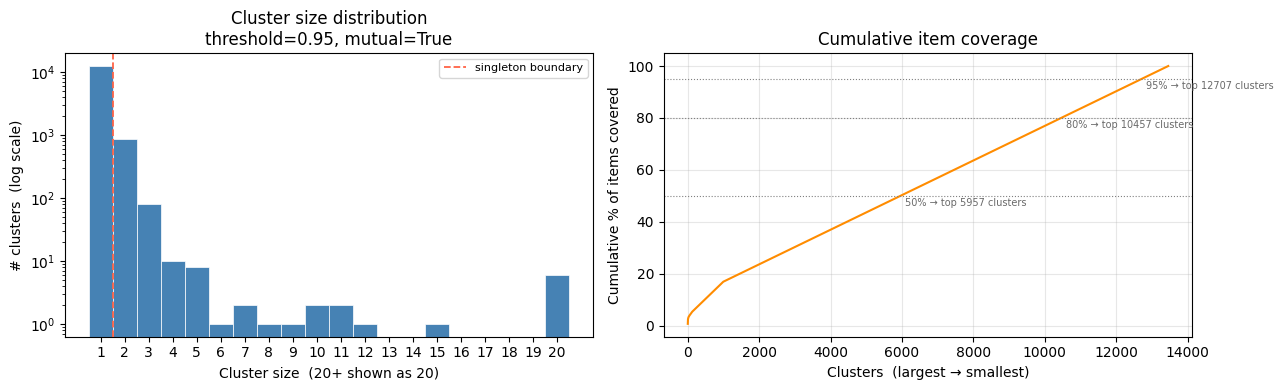

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Re-cluster val set with best threshold for sanity check
mask = all_s >= BEST_THRESHOLD
er_best, ec_best = all_i[mask], all_j[mask]
if MUTUAL:
    keep = [k for k, (gi, gj) in enumerate(zip(er_best, ec_best))
            if gj in nbr_sets_val[gi] and gi in nbr_sets_val[gj]]
    er_best, ec_best = er_best[keep], ec_best[keep]

val_id2cluster = edges_to_clusters(er_best, ec_best, N, val_ids)

# Invert: cluster_id → [item_ids]
cluster2items = defaultdict(list)
for iid, cid in val_id2cluster.items():
    cluster2items[cid].append(iid)

multi_clusters = {cid: members for cid, members in cluster2items.items() if len(members) > 1}
sing_clusters  = {cid: members for cid, members in cluster2items.items() if len(members) == 1}

# ── Summary ───────────────────────────────────────────────────────────────────
sizes_arr        = np.array([len(v) for v in cluster2items.values()])
n_total          = len(sizes_arr)
n_singletons     = int((sizes_arr == 1).sum())
n_multi          = int((sizes_arr > 1).sum())
n_items_in_multi = int(sizes_arr[sizes_arr > 1].sum())

print('━'*58)
print(f'  Total clusters            : {n_total:>8,}')
print(f'  Singletons  (size == 1)   : {n_singletons:>8,}  ({100*n_singletons/n_total:.1f}%)')
print(f'  Multi-item  (size >= 2)   : {n_multi:>8,}  ({100*n_multi/n_total:.1f}%)')
print(f'  Items in multi-clusters   : {n_items_in_multi:>8,}  ({100*n_items_in_multi/len(val_ids):.1f}% of val items)')
print(f'  Largest cluster           : {int(sizes_arr.max()):>8,}')
print(f'  Mean size (multi only)    : {sizes_arr[sizes_arr>1].mean():>8.2f}')
print('━'*58)

# Per-size table
print(f'\n{"Size":>5} | {"# clusters":>10} | {"% clusters":>10} | {"% items":>8}')
print('─'*44)
for sz in sorted(set(sizes_arr.tolist())):
    if sz > 15:
        break
    cnt = int((sizes_arr == sz).sum())
    print(f'{sz:>5} | {cnt:>10,} | {100*cnt/n_total:>9.2f}% | {100*cnt*sz/len(val_ids):>7.2f}%'
          + (' ← singleton' if sz == 1 else ''))
over15 = int((sizes_arr > 15).sum())
if over15:
    items_over15 = int(sizes_arr[sizes_arr > 15].sum())
    print(f'  >15 | {over15:>10,} | {100*over15/n_total:>9.2f}% | {100*items_over15/len(val_ids):>7.2f}%'
          + f'  (max={int(sizes_arr.max())})')

# ── Two-panel plot ────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram (log-y, cap at 20)
cap    = 20
bins   = np.arange(0.5, cap + 1.5, 1)
ax1.hist(np.clip(sizes_arr, 1, cap), bins=bins,
         color='steelblue', edgecolor='white', linewidth=0.5)
ax1.set_yscale('log')
ax1.set_xlabel('Cluster size  (20+ shown as 20)')
ax1.set_ylabel('# clusters  (log scale)')
ax1.set_title(f'Cluster size distribution\nthreshold={BEST_THRESHOLD}, mutual={MUTUAL}')
ax1.set_xticks(range(1, cap + 1))
ax1.axvline(1.5, color='tomato', linestyle='--', linewidth=1.3, label='singleton boundary')
ax1.legend(fontsize=8)

# Right: cumulative % of items covered (largest clusters first)
sorted_sizes = np.sort(sizes_arr)[::-1]
cum_pct = 100 * np.cumsum(sorted_sizes) / sorted_sizes.sum()
ax2.plot(np.arange(1, len(cum_pct) + 1), cum_pct, color='darkorange', linewidth=1.5)
ax2.set_xlabel('Clusters  (largest → smallest)')
ax2.set_ylabel('Cumulative % of items covered')
ax2.set_title('Cumulative item coverage')
ax2.grid(True, alpha=0.3)
for pct in [50, 80, 95]:
    idx = int(np.searchsorted(cum_pct, pct))
    ax2.axhline(pct, color='grey', linestyle=':', linewidth=0.8)
    ax2.annotate(f'{pct}% → top {idx+1} clusters',
                 xy=(idx, pct), xytext=(idx + max(1, n_total*0.01), pct - 4),
                 fontsize=7, color='dimgrey')

plt.tight_layout()
plt.show()


show_cluster() and print_cluster() defined.
--- 10 random MULTI-ITEM predicted clusters ---


/var/folders/wz/x7xqj0yj6ls_367syhygxjn40000gn/T/ipykernel_97352/1207621266.py:68: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


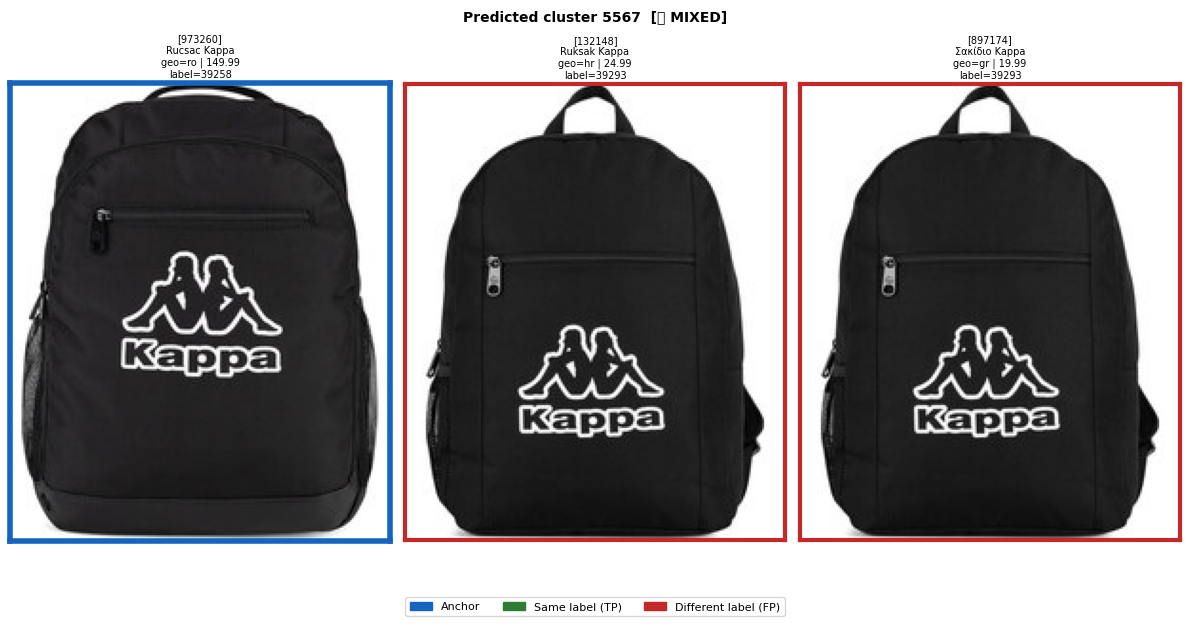

/var/folders/wz/x7xqj0yj6ls_367syhygxjn40000gn/T/ipykernel_97352/1207621266.py:68: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


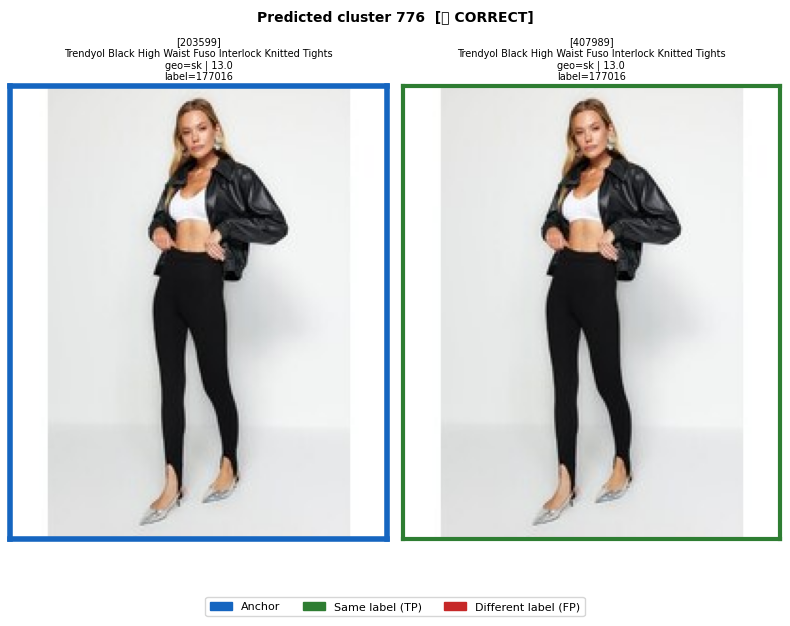

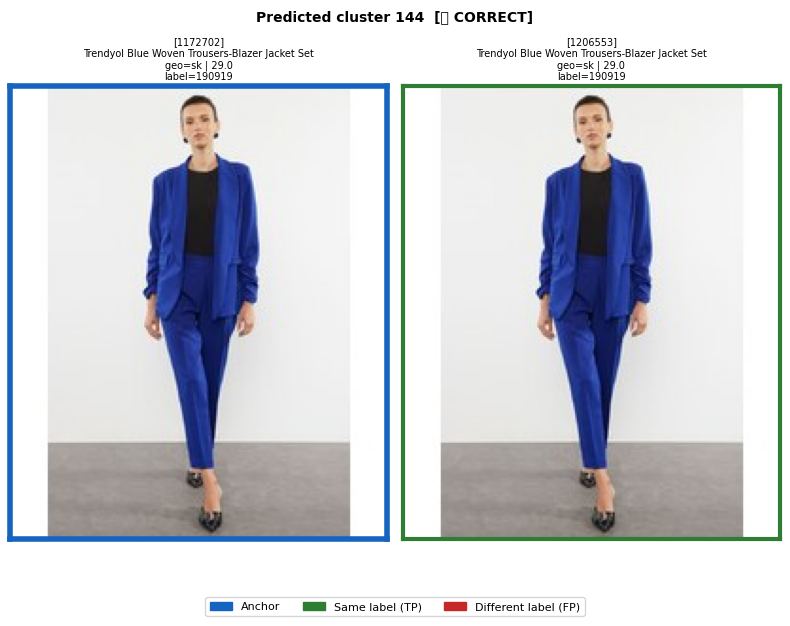

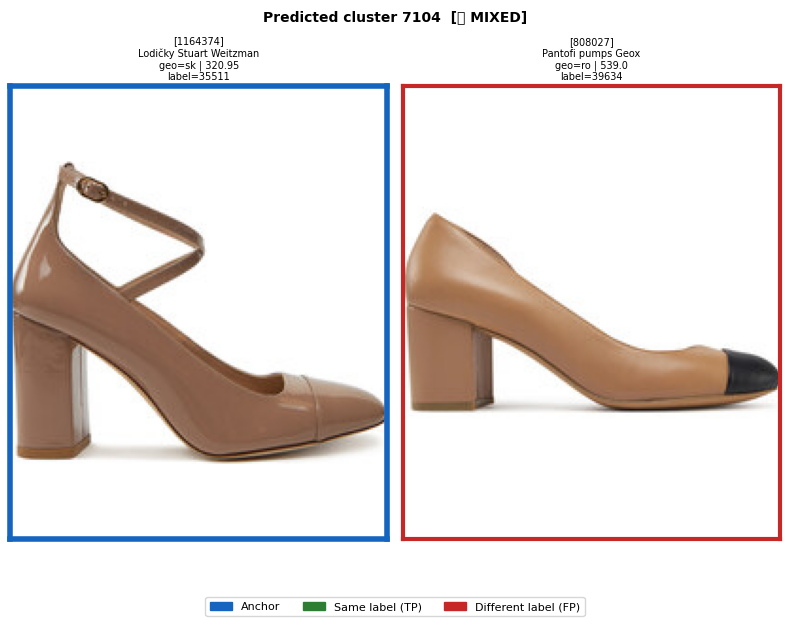

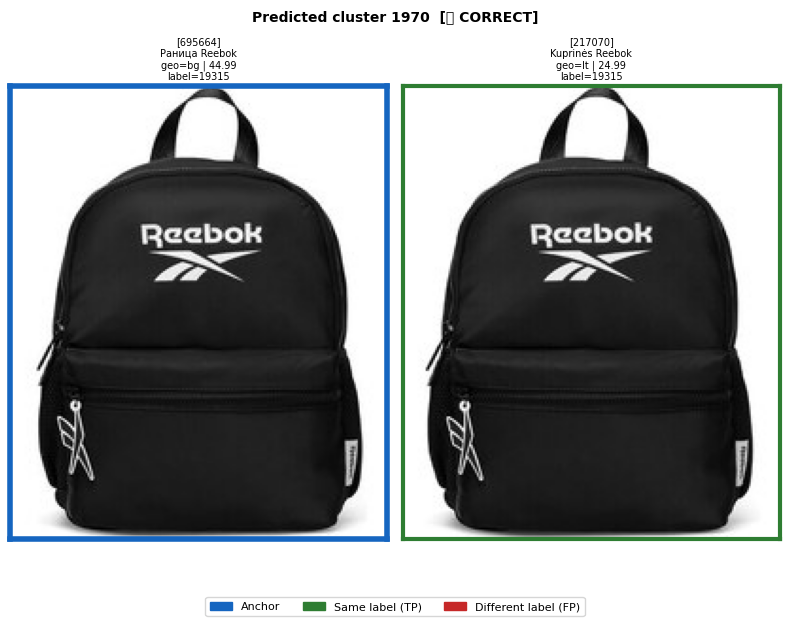

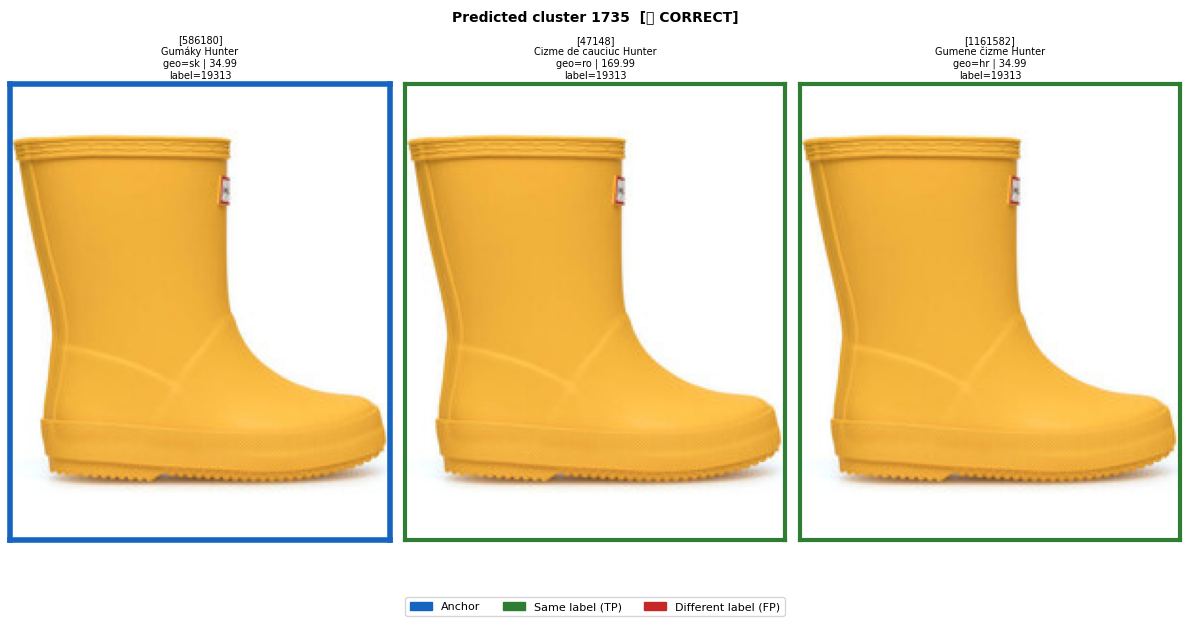

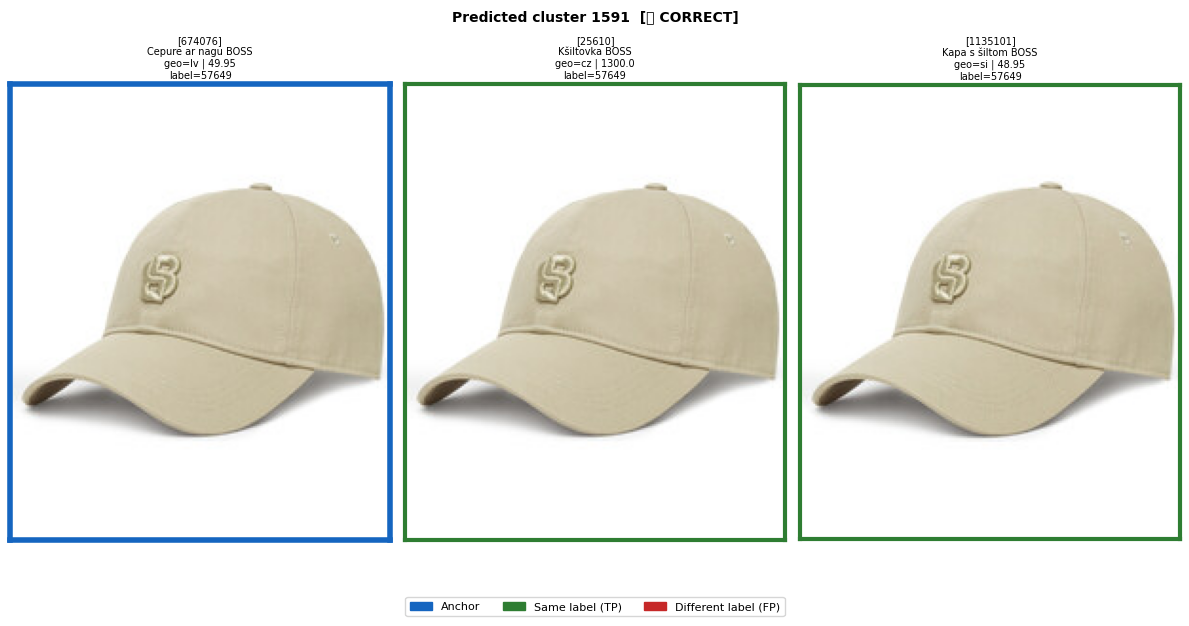

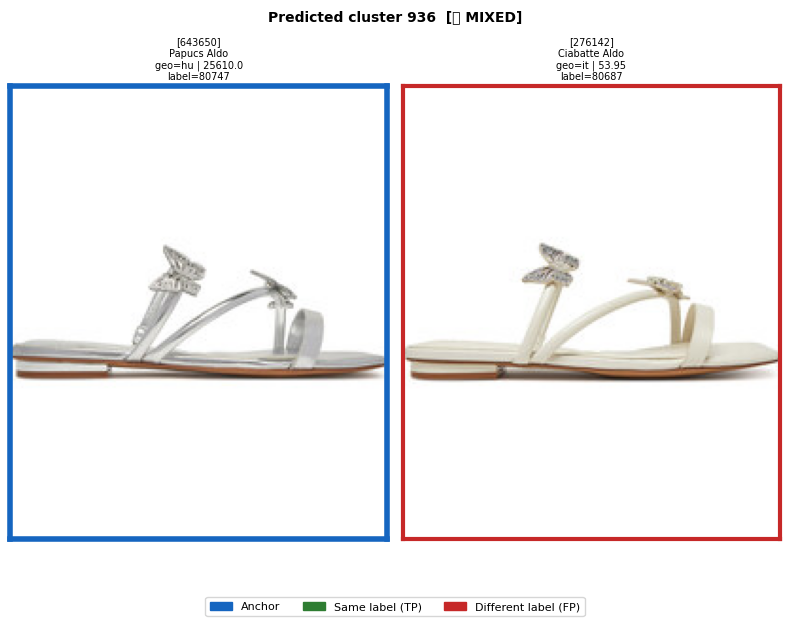

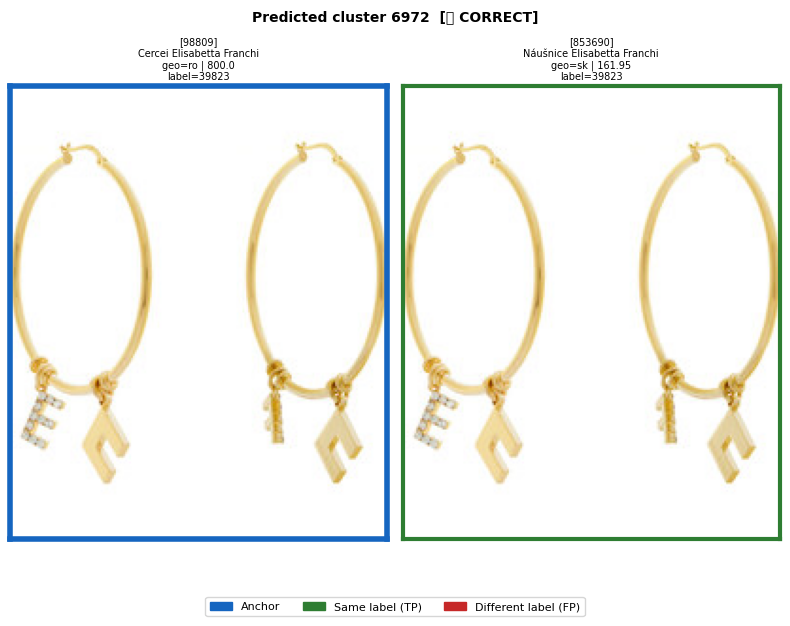

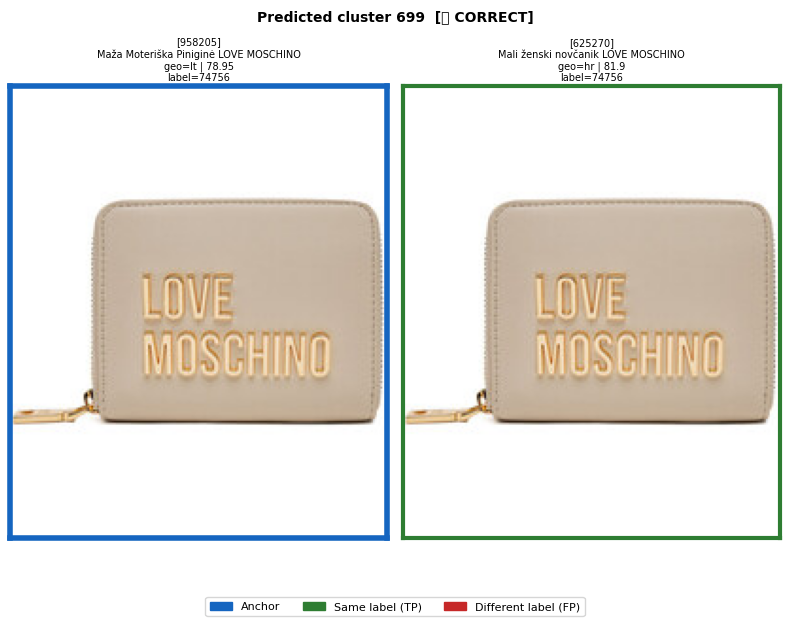

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

IMAGES_DIR = '/Users/matouskovar/FIT/images'  # DO NOT LIST — open per-item only

# Build a quick title lookup for the val items
val_meta = df_val_sample.set_index('itemId')[['title', 'geo', 'label']].to_dict('index')

def _load_img(item_id):
    path = os.path.join(IMAGES_DIR, f'{item_id}.jpg')
    try:
        return Image.open(path).convert('RGB')
    except Exception:
        return None

def show_cluster(cid, members, id2label=val_labels, text_chars=55):
    """
    Display a predicted cluster as a row of images (like show_text_neighbours).
    Border colour: blue=first item, green=correct duplicate, red=wrong label.
    """
    true_labels = [str(id2label.get(iid, '?')) for iid in members]
    is_correct  = len(set(true_labels)) == 1
    flag = '✅ CORRECT' if is_correct else '❌ MIXED'

    n_cols = len(members)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 6))
    if n_cols == 1:
        axes = [axes]

    ref_label = true_labels[0]

    for ax, iid, true_lbl in zip(axes, members, true_labels):
        img = _load_img(iid)
        if img:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'no image', ha='center', va='center',
                    fontsize=9, transform=ax.transAxes)
            ax.set_facecolor('#eeeeee')

        if iid == members[0]:
            color, lw = '#1565C0', 4   # blue — anchor item
        elif true_lbl == ref_label:
            color, lw = '#2e7d32', 3   # green — same true label
        else:
            color, lw = '#c62828', 3   # red — wrong label (FP)
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(lw)

        meta  = val_meta.get(iid, {})
        title = str(meta.get('title', 'N/A'))[:text_chars]
        geo   = meta.get('geo', '?')
        price = df_val_sample.set_index('itemId')['price'].get(iid, '') if 'price' in df_val_sample.columns else ''
        ax.set_title(f'[{iid}]\n{title}\ngeo={geo} | {price}\nlabel={true_lbl}', fontsize=7, pad=4)
        ax.set_xticks([])
        ax.set_yticks([])

    patches = [
        mpatches.Patch(color='#1565C0', label='Anchor'),
        mpatches.Patch(color='#2e7d32', label='Same label (TP)'),
        mpatches.Patch(color='#c62828', label='Different label (FP)'),
    ]
    fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=8,
               bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(f'Predicted cluster {cid}  [{flag}]', fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Legacy text-only version (kept for quick non-visual use)
def print_cluster(cid, members, id2label=val_labels):
    true_labels = [str(id2label.get(iid, '?')) for iid in members]
    is_correct  = len(set(true_labels)) == 1
    flag = '✅ CORRECT' if is_correct else '❌ MIXED'
    print(f'\n{"─"*70}')
    print(f'Predicted cluster {cid}  ({len(members)} items)  [{flag}]')
    print(f'{"─"*70}')
    for iid in members:
        meta  = val_meta.get(iid, {})
        title = str(meta.get('title', 'N/A'))[:80]
        geo   = meta.get('geo', '?')
        lbl   = str(id2label.get(iid, '?'))
        print(f'  [{iid}] geo={geo:3s}  label={lbl:>8s}  "{title}"')

print('show_cluster() and print_cluster() defined.')
print('--- 10 random MULTI-ITEM predicted clusters ---')
sample_multi = random.sample(list(multi_clusters.items()), min(10, len(multi_clusters)))
for cid, members in sample_multi:
    show_cluster(cid, members)


Multi-item clusters: 988
  Correct (all same label): 798  (80.8%)
  Bad    (mixed labels):    190  (19.2%)

--- 5 examples of BAD merges (FP — different true labels grouped together) ---


/var/folders/wz/x7xqj0yj6ls_367syhygxjn40000gn/T/ipykernel_97352/1207621266.py:68: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


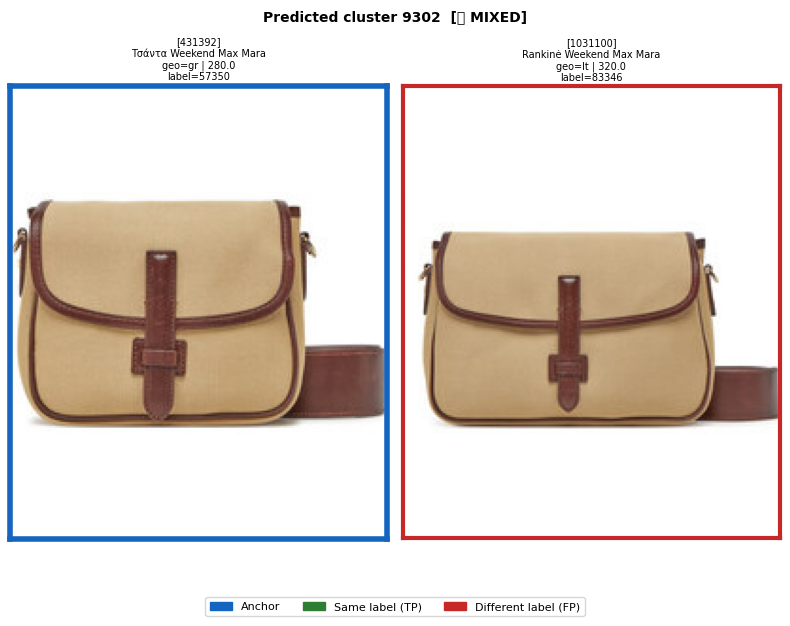

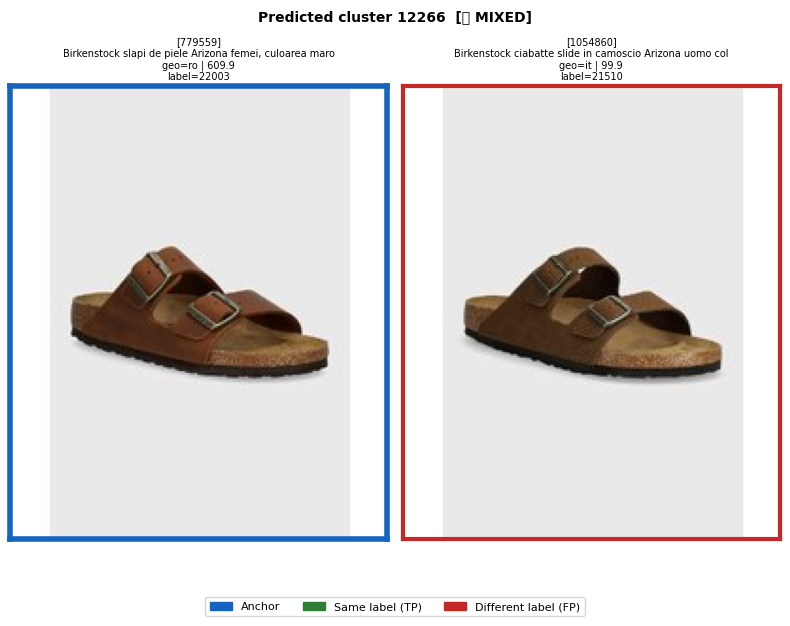

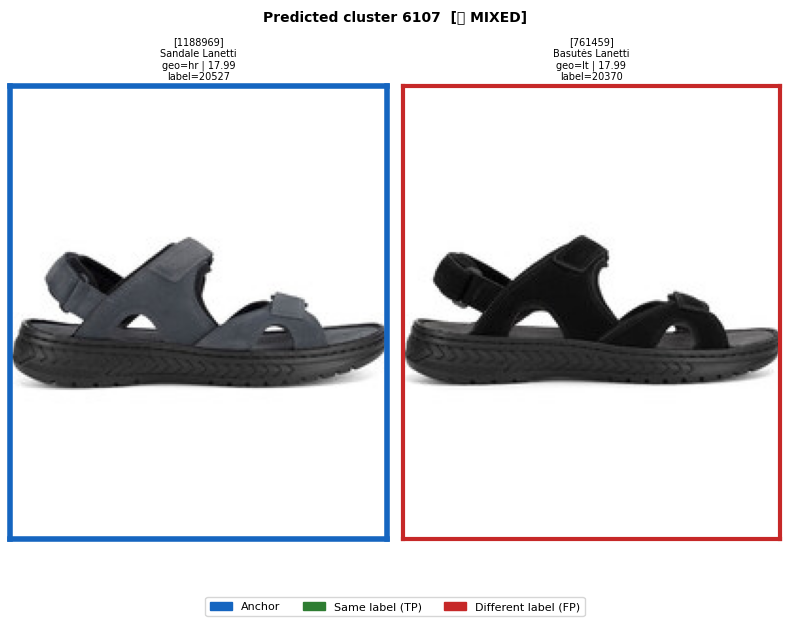

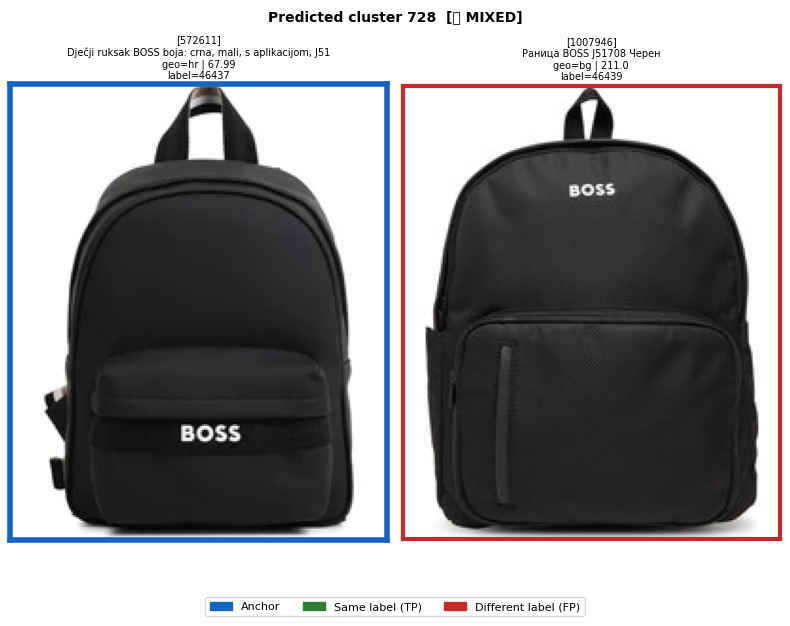

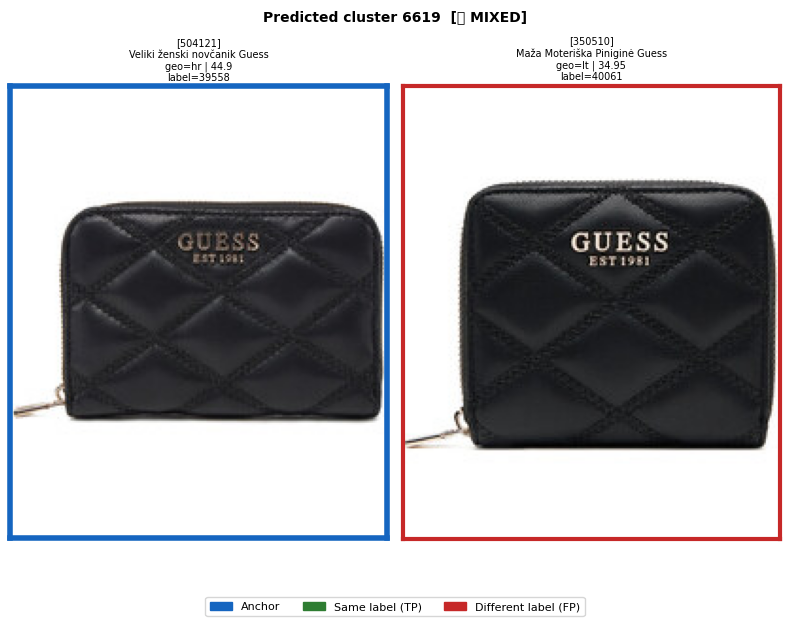

In [15]:
bad_clusters = {
    cid: members for cid, members in multi_clusters.items()
    if len(set(val_labels.get(iid, '?') for iid in members)) > 1
}
good_clusters = {
    cid: members for cid, members in multi_clusters.items()
    if len(set(val_labels.get(iid, '?') for iid in members)) == 1
}

print(f'Multi-item clusters: {len(multi_clusters):,}')
print(f'  Correct (all same label): {len(good_clusters):,}  ({100*len(good_clusters)/max(1,len(multi_clusters)):.1f}%)')
print(f'  Bad    (mixed labels):    {len(bad_clusters):,}  ({100*len(bad_clusters)/max(1,len(multi_clusters)):.1f}%)')

print('\n--- 5 examples of BAD merges (FP — different true labels grouped together) ---')
for cid, members in random.sample(list(bad_clusters.items()), min(5, len(bad_clusters))):
    show_cluster(cid, members)


True-positive groups split into multiple predicted clusters: 246

--- 5 examples of SPLIT true groups (FN — same product, different predicted clusters) ---


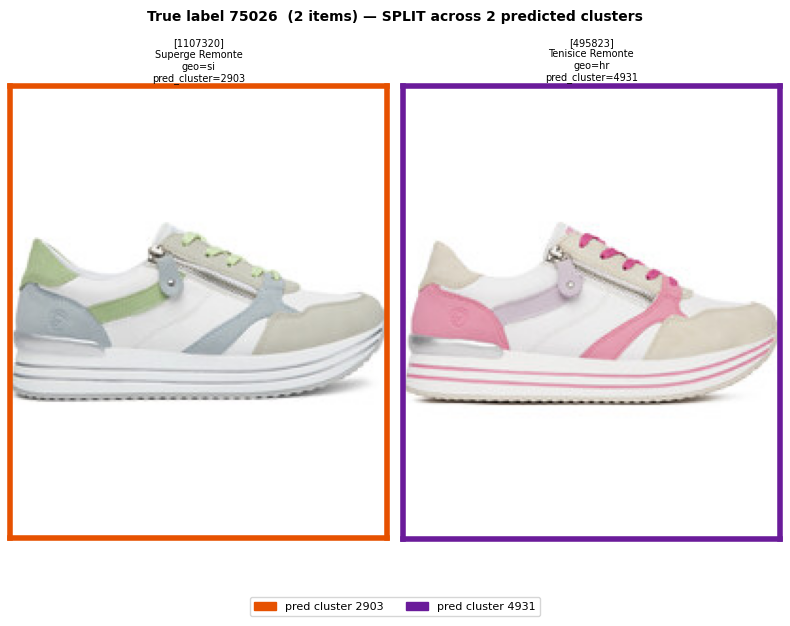

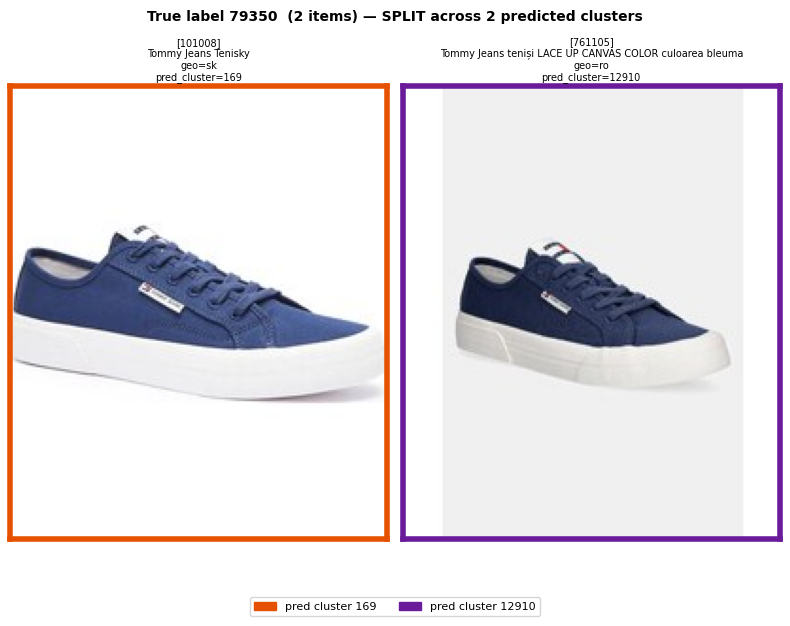

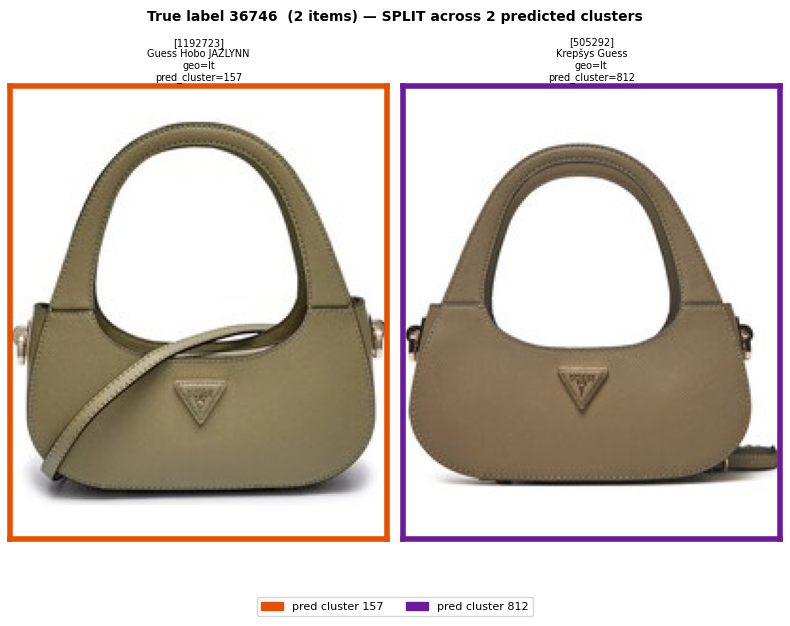

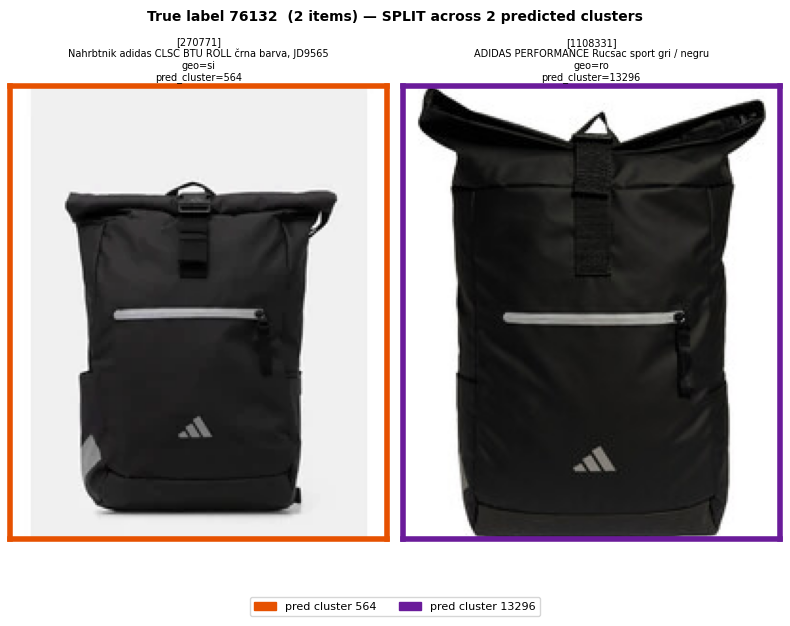

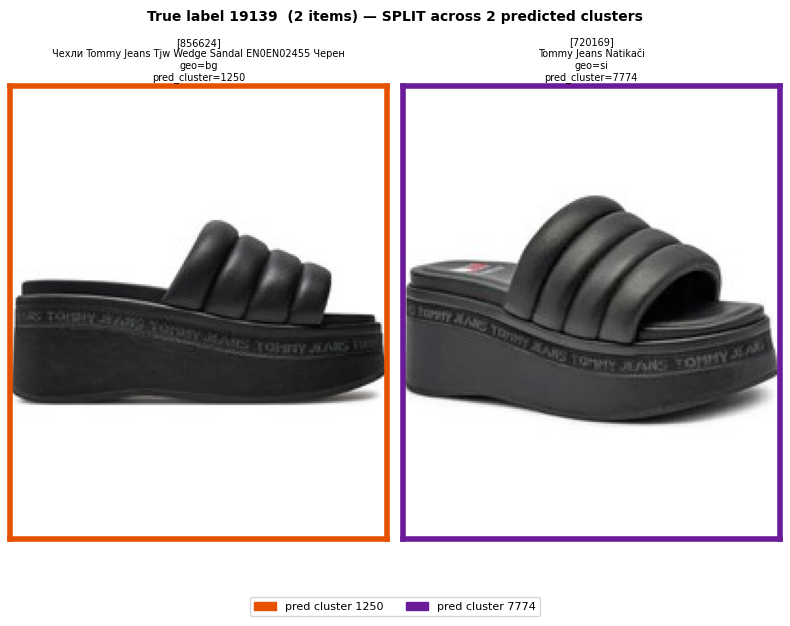

In [16]:
true_groups_val = defaultdict(list)
for iid in val_ids:
    true_groups_val[val_labels.get(iid)].append(iid)

split_true_labels = [
    (lbl, members) for lbl, members in true_groups_val.items()
    if len(members) >= 2
    and len(set(val_id2cluster[iid] for iid in members)) > 1
]

print(f'True-positive groups split into multiple predicted clusters: {len(split_true_labels):,}')
print('\n--- 5 examples of SPLIT true groups (FN — same product, different predicted clusters) ---')

for lbl, members in random.sample(split_true_labels, min(5, len(split_true_labels))):
    # Show all items of the true group, colour-coded by their predicted cluster id
    pred_clusters_for_group = sorted(set(val_id2cluster[iid] for iid in members))
    n_cols = len(members)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 6))
    if n_cols == 1:
        axes = [axes]

    # Assign a distinct colour per predicted cluster
    cluster_colors = ['#e65100', '#6a1b9a', '#00695c', '#1565C0', '#558b2f']
    pred_cid_to_color = {cid: cluster_colors[i % len(cluster_colors)]
                         for i, cid in enumerate(pred_clusters_for_group)}

    for ax, iid in zip(axes, members):
        img = _load_img(iid)
        if img:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, 'no image', ha='center', va='center',
                    fontsize=9, transform=ax.transAxes)
            ax.set_facecolor('#eeeeee')

        pred_c = val_id2cluster[iid]
        color  = pred_cid_to_color[pred_c]
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(4)

        meta  = val_meta.get(iid, {})
        title = str(meta.get('title', 'N/A'))[:55]
        geo   = meta.get('geo', '?')
        ax.set_title(f'[{iid}]\n{title}\ngeo={geo}\npred_cluster={pred_c}', fontsize=7, pad=4)
        ax.set_xticks([])
        ax.set_yticks([])

    patches = [mpatches.Patch(color=pred_cid_to_color[c], label=f'pred cluster {c}')
               for c in pred_clusters_for_group]
    fig.legend(handles=patches, loc='lower center', ncol=len(patches), fontsize=8,
               bbox_to_anchor=(0.5, -0.04))
    fig.suptitle(f'True label {lbl}  ({len(members)} items) — SPLIT across {len(pred_clusters_for_group)} predicted clusters',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()


## 8. Apply to `items_phase_2.csv` → submission

If phase 2 data exists, cluster it and write submission.

In [17]:
PHASE2_PATH = f'{DATA_DIR}/items_phase_2.csv'

if not os.path.exists(PHASE2_PATH):
    print(f'⚠️  {PHASE2_PATH} not found — skipping submission generation.')
    print('   Place items_phase_2.csv in data/ when available and re-run.')
else:
    print('Loading items_phase_2.csv...')
    df_p2 = pd.read_csv(PHASE2_PATH)
    df_p2['itemId'] = df_p2['itemId'].astype(str)
    print(f'  {len(df_p2):,} items')

    # Keep only items with embeddings
    have_emb = set(clip_emb_dict.keys()) & set(text_emb_dict.keys())
    p2_ids   = [iid for iid in df_p2['itemId'].tolist() if iid in have_emb]
    missing  = len(df_p2) - len(p2_ids)
    print(f'  Items with embeddings: {len(p2_ids):,}  (missing both: {missing:,})')

    print('Building phase-2 embedding matrix...')
    p2_mat = build_embedding_matrix(p2_ids, clip_emb_dict, text_emb_dict)
    print(f'  Shape: {p2_mat.shape}')

    print(f'\nRunning KNN at threshold={BEST_THRESHOLD} (mutual={MUTUAL}, K={TOP_K})...')
    N2 = p2_mat.shape[0]
    p2_mat_dev = p2_mat.to(device)
    p2_i, p2_j, p2_s = [], [], []
    p2_nbr = defaultdict(set)

    for start in range(0, N2, BLOCK):
        end   = min(start + BLOCK, N2)
        block = p2_mat_dev[start:end]
        sims  = torch.mm(block, p2_mat_dev.T)
        for bi in range(end - start):
            sims[bi, start + bi] = -2.0
        vals, idxs = torch.topk(sims, k=TOP_K, dim=1)
        for bi in range(end - start):
            gi = start + bi
            for ki in range(TOP_K):
                gj  = idxs[bi, ki].item()
                sim = vals[bi, ki].item()
                if gj > gi and sim >= BEST_THRESHOLD:
                    p2_i.append(gi); p2_j.append(gj); p2_s.append(sim)
                if sim >= BEST_THRESHOLD:
                    p2_nbr[gi].add(gj)
        if (start // BLOCK) % 20 == 0:
            print(f'  {start:>6}/{N2}', end='\r')

    p2_i = np.array(p2_i, dtype=np.int32)
    p2_j = np.array(p2_j, dtype=np.int32)

    if MUTUAL:
        keep = [k for k, (gi, gj) in enumerate(zip(p2_i, p2_j))
                if gj in p2_nbr[gi] and gi in p2_nbr[gj]]
        p2_i, p2_j = p2_i[keep], p2_j[keep]

    p2_id2cluster = edges_to_clusters(p2_i, p2_j, N2, p2_ids)

    # Items with no embeddings → each gets own singleton cluster
    next_cluster_id = max(p2_id2cluster.values()) + 1
    missing_ids = [iid for iid in df_p2['itemId'].tolist() if iid not in p2_id2cluster]
    for iid in missing_ids:
        p2_id2cluster[iid] = next_cluster_id
        next_cluster_id += 1

    # Invert to get cluster → items
    p2_cluster2items = defaultdict(list)
    for iid, cid in p2_id2cluster.items():
        p2_cluster2items[cid].append(iid)

    # Enforce max 100 per line: split large clusters
    output_lines = []
    MAX_PER_LINE = 100
    for cid, members in p2_cluster2items.items():
        for chunk_start in range(0, len(members), MAX_PER_LINE):
            chunk = members[chunk_start:chunk_start + MAX_PER_LINE]
            output_lines.append(','.join(chunk))

    out_path = f'{NOTEBOOK_DIR}/submission_phase2_baseline.csv'
    with open(out_path, 'w') as f:
        f.write('\n'.join(output_lines))

    total_clusters = len(p2_cluster2items)
    multi_p2 = sum(1 for m in p2_cluster2items.values() if len(m) > 1)
    print(f'\n✅ Submission written → {out_path}')
    print(f'   Lines: {len(output_lines):,}  |  Unique clusters: {total_clusters:,}  |  Multi-item: {multi_p2:,}')
    print(f'   All items covered: {len(p2_id2cluster) == len(df_p2)}')

⚠️  /Users/matouskovar/FIT/adm-sp/data/items_phase_2.csv not found — skipping submission generation.
   Place items_phase_2.csv in data/ when available and re-run.


## 9. Quick phase-1 items sanity check (same pipeline)

Phase-1 items share the same embedding space. Let's also sanity-check a few clusters on them for completeness (no ground truth, just visual check).

In [18]:
# Quick check: what fraction of phase-1 items have embeddings?
df_p1 = pd.read_csv(f'{DATA_DIR}/items_phase_1.csv')
df_p1['itemId'] = df_p1['itemId'].astype(str)
have_emb = set(clip_emb_dict.keys()) & set(text_emb_dict.keys())
p1_with_emb = df_p1['itemId'].isin(have_emb).sum()
print(f'Phase-1 items: {len(df_p1):,}')
print(f'  With embeddings: {p1_with_emb:,}  ({100*p1_with_emb/len(df_p1):.1f}%)')

Phase-1 items: 199,835
  With embeddings: 199,835  (100.0%)
